<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Naive Bayes on Breast Cancer Dataset</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Apply Gaussian Naive Bayes on the Breast Cancer dataset.</li>
<li>Evaluate its performance using standard classification metrics.</li>
<li>Compare results with the SVM model trained on the same data earlier.</li>
<li>Visualize the decision boundary using two features.</li>
</ol>
I already trained an SVM on this dataset. Now let's see how 
Naive Bayes - a much simpler, probability-based model - performs 
on the exact same problem.
</div>

In [1]:
# Importing all libraries needed for this notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Loading the Dataset</b>
</h2>
<div style="font-family:'Times New Roman';">
Same dataset as before - the Breast Cancer dataset, where the goal 
is to predict whether a tumor is <b>malignant (0)</b> or 
<b>benign (1)</b> based on 30 numerical features.
</div>

In [2]:
# Loading the dataset
data = load_breast_cancer()

# Converting to a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Shape of data:", df.shape)
print("Target classes:", data.target_names)
df.head()

Shape of data: (569, 31)
Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Splitting the Data</b>
</h2>
<div style="font-family:'Times New Roman';">
Splitting into training and testing sets, just like before, 
so we can fairly evaluate the model on unseen data.
</div>

In [3]:
# Separating features and target
X = df.drop('target', axis=1)
y = df['target']

# Splitting into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (455, 30)
Testing set shape: (114, 30)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Does Naive Bayes Need Feature Scaling?</b>
</h2>
<div style="font-family:'Times New Roman';">
Unlike SVM, <b>Gaussian Naive Bayes doesn't strictly require feature 
scaling</b>.
<br><br>
Here's why: SVM cares about <b>distances</b> between points (dot 
products), so features with large ranges can dominate. Naive Bayes, 
on the other hand, calculates a <b>separate mean and variance for 
each feature, for each class</b> - so each feature is effectively 
already on its "own scale" internally.
<br><br>
That said, scaling doesn't hurt and can sometimes help with 
numerical stability. Let's train the model <b>without scaling first</b>, 
since that's the more common approach for Naive Bayes, and then 
quickly check if scaling changes anything.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Training Gaussian Naive Bayes</b>
</h2>
<div style="font-family:'Times New Roman';">
Now let's train a <b>GaussianNB</b> model on the unscaled training 
data. Behind the scenes, this calculates the mean and variance of 
each of the 30 features, separately for malignant and benign tumors - 
exactly like our from-scratch implementation in the previous notebook, 
just applied to 30 features instead of 2.
</div>

In [4]:
# Creating and training the model
model = GaussianNB()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Evaluating the Model</b>
</h2>
<div style="font-family:'Times New Roman';">
Let's check the model's accuracy, classification report, and 
confusion matrix on the test set.
</div>

In [6]:
# Making predictions on the test set
y_pred = model.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

# Printing classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 93.86%

Classification Report:

              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



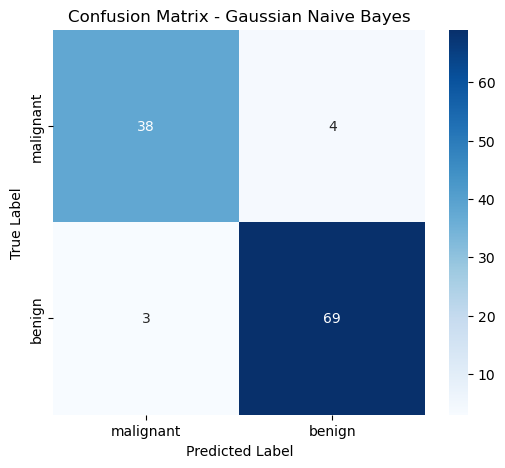

In [7]:
# Computing and visualizing the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)

plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Gaussian Naive Bayes Accuracy: 93.86%
Linear SVM Accuracy:           97.37%


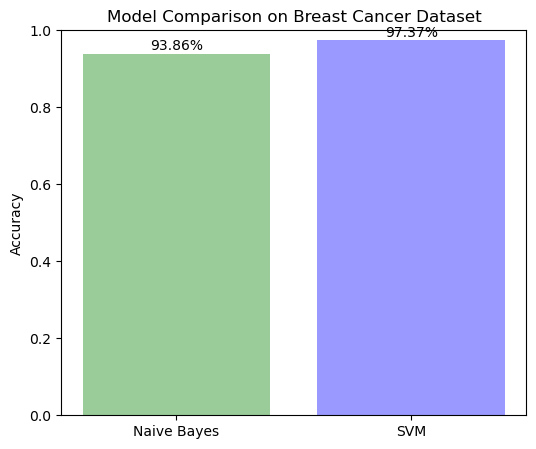

In [8]:
from sklearn.svm import SVC

# Scaling features for SVM (since SVM DOES need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training SVM
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

# Comparing both models
print(f"Gaussian Naive Bayes Accuracy: {accuracy * 100:.2f}%")
print(f"Linear SVM Accuracy:           {svm_accuracy * 100:.2f}%")

# Visualizing the comparison
plt.figure(figsize=(6, 5))
plt.bar(['Naive Bayes', 'SVM'], [accuracy, svm_accuracy], color=['#99CC99', '#9999FF'])
plt.title("Model Comparison on Breast Cancer Dataset")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, acc in enumerate([accuracy, svm_accuracy]):
    plt.text(i, acc + 0.01, f"{acc*100:.2f}%", ha='center')

plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing the Decision Boundary (Using 2 Features)</b>
</h2>
<div style="font-family:'Times New Roman';">
Just like we did with SVM, let's pick two features and visualize 
how Naive Bayes separates the two classes. 
<br><br>
Remember from the previous notebook - Naive Bayes decision boundaries 
come from comparing <b>Gaussian "bumps"</b> for each class, so they 
can look quite different from SVM's straight-line boundaries.
</div>

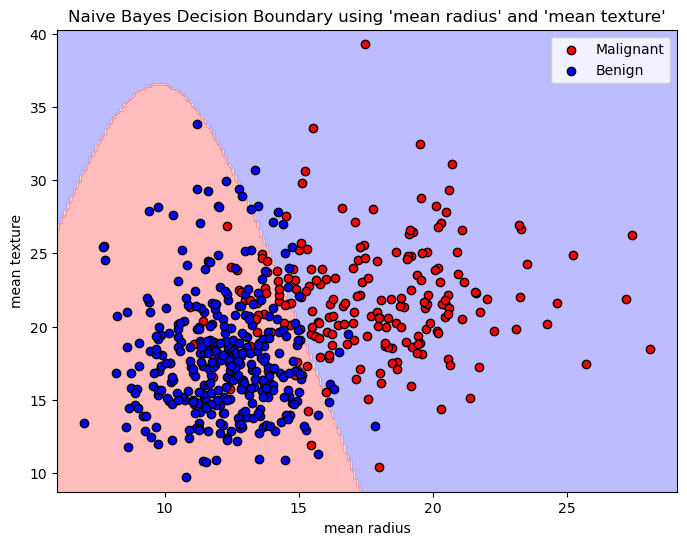

In [9]:
# Picking the same two features used in the SVM notebook for fair comparison
feature1 = 'mean radius'
feature2 = 'mean texture'

X_2d = df[[feature1, feature2]].values
y_2d = df['target'].values

# Training Naive Bayes on just these 2 features
model_2d = GaussianNB()
model_2d.fit(X_2d, y_2d)

# Creating a mesh grid to plot the decision boundary
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))

# Predicting over the grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')

plt.scatter(X_2d[y_2d == 0][:, 0], X_2d[y_2d == 0][:, 1],
            color='red', label='Malignant', edgecolors='k')
plt.scatter(X_2d[y_2d == 1][:, 0], X_2d[y_2d == 1][:, 1],
            color='blue', label='Benign', edgecolors='k')

plt.title(f"Naive Bayes Decision Boundary using '{feature1}' and '{feature2}'")
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Probability Estimates</b>
</h2>
<div style="font-family:'Times New Roman';">
One nice feature of Naive Bayes is that it gives genuinely 
meaningful <b>probability estimates</b> using 
<code>predict_proba()</code> - "how confident is the model in its 
prediction?"
<br><br>
Let's look at a few test samples and see the predicted probabilities 
for each class.
</div>

In [10]:
# Getting probability estimates for the first 10 test samples
probabilities = model.predict_proba(X_test[:10])

# Creating a readable DataFrame
prob_df = pd.DataFrame(probabilities, columns=data.target_names)
prob_df['Predicted'] = model.predict(X_test[:10])
prob_df['Actual'] = y_test.values[:10]

prob_df

,malignant,benign,Predicted,Actual
0,1.000000e+00,2.641700e-92,0,0
1,9.685177e-18,1.000000e+00,1,1
2,9.999948e-01,5.195387e-06,0,0
3,3.397346e-01,6.602654e-01,1,1
4,1.000000e+00,1.394117e-139,0,0
5,1.536709e-12,1.000000e+00,1,1
6,5.795119e-13,1.000000e+00,1,1
7,1.000000e+00,1.289240e-52,0,0
8,1.000000e+00,1.405073e-32,0,0
9,1.000000e+00,1.064514e-110,0,0


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Applied <b>Gaussian Naive Bayes</b> on the real Breast Cancer dataset.</li>
<li>Confirmed that Naive Bayes <b>doesn't strictly require feature scaling</b>, 
unlike SVM.</li>
<li>Compared accuracy directly with a <b>linear SVM</b> on the same 
train-test split.</li>
<li>Visualized the <b>decision boundary</b> using two features and 
saw how it differs in shape from SVM's boundary.</li>
<li>Explored Naive Bayes' built-in <b>probability estimates</b> via 
<code>predict_proba()</code>.</li>
</ul>
Naive Bayes is much <b>simpler and faster</b> than SVM, and on this 
dataset, it performs surprisingly close to SVM despite its strong 
independence assumption - a great example of why "naive" doesn't 
mean "bad"!
</div>